# Práctica 2 — Sección 3.7
## Clasificación, evaluación e integración

**Responsable:** Alvaro

Este notebook consume las matrices de características generadas en la sección 3.6
(`practica_2_descriptores.ipynb`: LBP+HOG, BoW, Fisher Vector y el descriptor
propio) y entrena/evalúa los clasificadores pedidos por el enunciado.

**Entrada:** `features/{lbp_hog,bow,fisher,propio}_features.npz`, generados por
3.6. Si alguno no existe todavía, este notebook lo reconstruye corriendo el
pipeline completo (3.1-3.6, solo LBP+HOG) sobre el dataset — más lento, así que
conviene correr primero `practica_2_descriptores.ipynb` completo.

**Salida:**
- Tabla comparativa de accuracy / F1 por clase (`features/resultados_clasificacion.csv`).
- Figuras comparativas y matriz de confusión en `figs/`.

---
### Contenido
1. Imports y configuración
2. Reconstrucción del pipeline base (solo si falta `lbp_hog_features.npz`)
3. Carga de las matrices de características (3.6) y conjuntos a comparar
4. Estrategia de validación: k-fold estratificado
5. k-Nearest Neighbors
6. Support Vector Machines
7. Random Forest (y variantes de boosting si están disponibles)
8. Comparación de descriptores y modelos
9. Conclusiones

## 1. Imports y configuración

Todos los imports del notebook van acá (incluidos los que usan las secciones de
más abajo), para no ir importando sobre la marcha.

In [1]:
import os, random, pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    TIENE_XGBOOST = True
except ImportError:
    TIENE_XGBOOST = False

try:
    from lightgbm import LGBMClassifier
    TIENE_LIGHTGBM = True
except ImportError:
    TIENE_LIGHTGBM = False

# Solo hacen falta si features/lbp_hog_features.npz no existe todavia y hay
# que reconstruir la matriz desde las imagenes (seccion 2).
from skimage.feature import local_binary_pattern, hog

random.seed(42)
np.random.seed(42)
RANDOM_STATE = 42
KFOLDS = 5   # el enunciado pide k >= 5

FIGS = "figs"
FEATS = "features"
os.makedirs(FIGS, exist_ok=True)
os.makedirs(FEATS, exist_ok=True)

def guardar(nombre):
    ruta = os.path.join(FIGS, nombre)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print("guardado:", ruta)

def etiqueta_corta(clase):
    return (str(clase).replace("Tomato_", "").replace("Tomato__", "")
                 .replace("_", " ").replace("  ", " ").strip())

print("Imports listos. xgboost:", TIENE_XGBOOST, "| lightgbm:", TIENE_LIGHTGBM)

Imports listos. xgboost: False | lightgbm: False


## 2. Reconstrucción del pipeline base (solo respaldo)

Copia fiel de `practica_2_descriptores.ipynb` (mismo criterio que usan
`practica_2_bordes_esquinas.ipynb` y `practica_2_descriptores.ipynb` — si el
pipeline acordado por el grupo cambia, actualizar `CONFIG_PIPELINE` en los
notebooks). Esta función **solo se ejecuta** si `features/lbp_hog_features.npz`
no existe todavía (ver sección 3); si ya corriste 3.6, esta celda no hace nada
al llamarse.

In [2]:
def to_grayscale(bgr):
    b, g, r = bgr[:, :, 0], bgr[:, :, 1], bgr[:, :, 2]
    return (0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)

def aplicar_filtro(gray, filtro, ksize):
    if filtro == 'gaussian':
        return cv2.GaussianBlur(gray, (ksize, ksize), 0)
    elif filtro == 'median':
        return cv2.medianBlur(gray, ksize)
    raise ValueError("filtro debe ser 'gaussian' o 'median'")

def cdf_histograma(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    cdf = np.cumsum(hist)
    return (cdf - cdf.min()) / (cdf.max() - cdf.min()) * 255

def ecualizar_histograma(gray):
    lut = cdf_histograma(gray).astype(np.uint8)
    return cv2.LUT(gray, lut)

def orient_leaf_as_foreground(mask):
    border = np.concatenate([mask[0, :], mask[-1, :], mask[:, 0], mask[:, -1]])
    return cv2.bitwise_not(mask) if border.mean() > 100 else mask

def segmentar(gray, metodo, global_t=127):
    if metodo == 'global':
        _, m = cv2.threshold(gray, global_t, 255, cv2.THRESH_BINARY)
        return orient_leaf_as_foreground(m)
    elif metodo == 'otsu':
        _, m = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        return orient_leaf_as_foreground(m)
    raise ValueError("método desconocido: " + str(metodo))

def aplicar_morfologia(mask, operacion, ksize):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    if operacion == 'erosion':
        return cv2.erode(mask, kernel, iterations=1)
    elif operacion == 'dilatacion':
        return cv2.dilate(mask, kernel, iterations=1)
    elif operacion == 'apertura':
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    elif operacion == 'cierre':
        return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    raise ValueError("operación desconocida: " + str(operacion))

def construir_pipeline(filtro='gaussian', ksize_filtro=5, contraste=False,
                       metodo_seg='otsu', global_t=127, operaciones_morf=()):
    pasos = [('Gris', to_grayscale)]
    if contraste:
        pasos.append(('Contraste (CDF)', ecualizar_histograma))
    pasos.append(('Filtro', lambda img: aplicar_filtro(img, filtro, ksize_filtro)))
    pasos.append(('Segmentacion', lambda img: segmentar(img, metodo_seg, global_t)))
    for op, ksize in operaciones_morf:
        pasos.append((op.capitalize() + " (k=" + str(ksize) + ")",
                      lambda img, op=op, ksize=ksize: aplicar_morfologia(img, op, ksize)))
    return pasos

def ejecutar_pipeline(bgr, pasos):
    actual = bgr
    for _, fn in pasos:
        actual = fn(actual)
    return actual

CONFIG_PIPELINE = dict(
    filtro='gaussian', ksize_filtro=5, contraste=True,
    metodo_seg='otsu', operaciones_morf=[('dilatacion', 11), ('erosion', 3)],
)

def generar_lbp_hog_desde_cero(n_por_clase=40, tam_descriptor=(128, 128)):
    '''Repite 3.1-3.6 (solo LBP+HOG) sobre el dataset y arma (X, y, n_lbp).
    Requiere PlantVillage (kagglehub o LOCAL_DATASET) - solo se usa como
    respaldo si 3.6 no se corrio antes.'''
    LOCAL_DATASET = False
    if LOCAL_DATASET:
        path = "../../../../../Downloads/archive"   # ajustar a tu ruta
    else:
        import kagglehub
        path = kagglehub.dataset_download("emmarex/plantdisease")
    data_dir = os.path.join(path, "PlantVillage")

    clases_disp = sorted(d for d in os.listdir(data_dir)
                          if os.path.isdir(os.path.join(data_dir, d))
                          and d.lower() != "plantvillage")
    patrones = ["Tomato_healthy", "Tomato_Early_blight", "Tomato_Septoria", "YellowLeaf"]
    clases_foco = []
    for p in patrones:
        match = [c for c in clases_disp if p.lower() in c.lower()]
        if match:
            clases_foco.append(match[0])

    def imagenes_de_clase(clase, n, seed=42):
        random.seed(seed)
        cdir = os.path.join(data_dir, clase)
        exts = ('.png', '.jpg', '.jpeg', '.bmp')
        imgs = sorted(f for f in os.listdir(cdir) if f.lower().endswith(exts))
        return [os.path.join(cdir, f) for f in random.sample(imgs, min(n, len(imgs)))]

    pipeline_final = construir_pipeline(**CONFIG_PIPELINE)

    lbp_radio, lbp_puntos, lbp_metodo = 1, 8, 'uniform'
    lbp_n_bins = lbp_puntos + 2
    hog_params = dict(orientations=9, pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), block_norm='L2-Hys')

    def extraer(bgr, mascara):
        gray = to_grayscale(bgr)
        gray = cv2.bitwise_and(gray, gray, mask=mascara)
        gray = cv2.resize(gray, tam_descriptor, interpolation=cv2.INTER_AREA)
        lbp_img = local_binary_pattern(gray, lbp_puntos, lbp_radio, method=lbp_metodo)
        h_lbp, _ = np.histogram(lbp_img.ravel(), bins=lbp_n_bins, range=(0, lbp_n_bins))
        h_lbp = h_lbp.astype(np.float64); h_lbp /= (h_lbp.sum() + 1e-7)
        h_hog = hog(gray, **hog_params)
        return np.concatenate([h_lbp, h_hog])

    filas, rutas, vectores = [], [], []
    for clase in clases_foco:
        for ruta in imagenes_de_clase(clase, n_por_clase):
            bgr = cv2.imread(ruta)
            mascara = ejecutar_pipeline(bgr, pipeline_final)
            vectores.append(extraer(bgr, mascara))
            filas.append(clase)
            rutas.append(ruta)

    X = np.vstack(vectores)
    y = np.array(filas)
    np.savez(os.path.join(FEATS, "lbp_hog_features.npz"), X=X, y=y, n_lbp=lbp_n_bins,
              rutas=np.array(rutas))
    print("Generado desde cero:", X.shape, "-> guardado en features/lbp_hog_features.npz")
    return X, y, lbp_n_bins

## 3. Carga de las matrices de características y conjuntos a comparar

Se cargan las cuatro salidas de 3.6 (LBP+HOG, BoW, Fisher Vector, descriptor
propio). Todas comparten el mismo orden de imágenes (se verifica comparando la
columna `rutas` de cada `.npz`), así que se pueden concatenar por columnas para
armar combinaciones.

El enunciado (sección 4, Experimentos) pide comparar el desempeño de los
descriptores por separado y evaluar si combinarlos mejora el resultado.

In [3]:
def cargar_npz(nombre):
    ruta = os.path.join(FEATS, f"{nombre}_features.npz")
    if not os.path.exists(ruta):
        return None
    d = np.load(ruta, allow_pickle=True)
    return d

d_lbp_hog = cargar_npz("lbp_hog")
if d_lbp_hog is None:
    print("[!] No se encontró features/lbp_hog_features.npz -> se reconstruye desde cero.")
    X_lbp_hog, y, N_LBP = generar_lbp_hog_desde_cero()
    rutas_ref = None
else:
    X_lbp_hog, y, N_LBP = d_lbp_hog["X"], d_lbp_hog["y"], int(d_lbp_hog["n_lbp"])
    rutas_ref = d_lbp_hog["rutas"]
    print("Cargado lbp_hog_features.npz:", X_lbp_hog.shape)

CONJUNTOS_DESCRIPTORES = {
    "LBP":     X_lbp_hog[:, :N_LBP],
    "HOG":     X_lbp_hog[:, N_LBP:],
    "LBP+HOG": X_lbp_hog,
}

# BoW, Fisher y descriptor propio (seccion 3.6, notebook aparte) - opcionales:
# si todavia no existen, se sigue solo con LBP/HOG/LBP+HOG.
for nombre_archivo, nombre_conjunto in [("bow", "BoW"), ("fisher", "Fisher"), ("propio", "Propio")]:
    d = cargar_npz(nombre_archivo)
    if d is None:
        print(f"[!] features/{nombre_archivo}_features.npz no existe todavía -> se omite '{nombre_conjunto}'.")
        continue
    if rutas_ref is not None and not (d["rutas"] == rutas_ref).all():
        print(f"[!] {nombre_archivo}: las rutas no coinciden con lbp_hog -> se omite (filas desalineadas).")
        continue
    CONJUNTOS_DESCRIPTORES[nombre_conjunto] = d["X"]
    print(f"Cargado {nombre_archivo}_features.npz:", d["X"].shape)

if len(CONJUNTOS_DESCRIPTORES) > 3:
    CONJUNTOS_DESCRIPTORES["Todos"] = np.hstack(
        [X for nombre, X in CONJUNTOS_DESCRIPTORES.items() if nombre not in ("LBP", "HOG", "LBP+HOG")]
        + [X_lbp_hog]
    )

print("\nConjuntos de descriptores disponibles:")
for nombre, X in CONJUNTOS_DESCRIPTORES.items():
    print(f"  {nombre:<10} dim = {X.shape[1]}")

Cargado lbp_hog_features.npz: (160, 1774)
Cargado bow_features.npz: (160, 64)
Cargado fisher_features.npz: (160, 8192)
Cargado propio_features.npz: (160, 16)

Conjuntos de descriptores disponibles:
  LBP        dim = 10
  HOG        dim = 1764
  LBP+HOG    dim = 1774
  BoW        dim = 64
  Fisher     dim = 8192
  Propio     dim = 16
  Todos      dim = 10046


## 4. Estrategia de validación: k-fold estratificado

El dataset no trae una partición train/test, así que la métrica se calcula con
k-fold (k ≥ 5, acá `KFOLDS = 5`), estratificado para mantener la proporción de
clases en cada fold. Para cada combinación (conjunto de descriptores,
clasificador) se usa `cross_val_predict` para obtener una predicción
out-of-fold de **cada** imagen (cada muestra se predice con un modelo que no
la vio en entrenamiento) y sobre eso se calculan accuracy, F1 por clase y la
matriz de confusión — así se evita optimismo por data leakage.

In [4]:
kfold = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=RANDOM_STATE)

def evaluar(modelo, X_sub, y_eval, kfold=kfold):
    '''cross_val_predict -> accuracy, F1 macro, F1 por clase y matriz de confusion,
    todo calculado sobre predicciones out-of-fold (nunca sobre datos de entrenamiento).'''
    y_pred = cross_val_predict(modelo, X_sub, y_eval, cv=kfold)
    acc = accuracy_score(y_eval, y_pred)
    f1_macro = f1_score(y_eval, y_pred, average="macro")
    reporte = classification_report(y_eval, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_eval, y_pred, labels=sorted(set(y_eval)))
    return dict(accuracy=acc, f1_macro=f1_macro, reporte=reporte, cm=cm, y_pred=y_pred)

RESULTADOS = []   # se va llenando en las secciones 5-7: (descriptor, modelo, metricas)

## 5. k-Nearest Neighbors

Se prueban varios valores de `k` (impares, para evitar empates en un problema
de 4 clases) sobre cada conjunto de descriptores, con features estandarizadas
(kNN es sensible a la escala y los distintos descriptores no están en el mismo
rango).

In [5]:
VALORES_K = [3, 5, 7, 9, 11]
knn_filas = []

for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for k in VALORES_K:
        modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
        r = evaluar(modelo, X_sub, y)
        knn_filas.append({"descriptor": nombre_desc, "k": k,
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": f"kNN (k={k})", **r})

df_knn = pd.DataFrame(knn_filas)
print(df_knn.pivot(index="k", columns="descriptor", values="accuracy").round(3))

MEJOR_KNN = (df_knn.sort_values("accuracy", ascending=False)
                    .groupby("descriptor").first().reset_index())
MEJOR_KNN

descriptor    BoW  Fisher    HOG    LBP  LBP+HOG  Propio  Todos
k                                                              
3           0.531   0.769  0.394  0.656    0.400   0.638  0.750
5           0.544   0.756  0.412  0.681    0.412   0.650  0.769
7           0.531   0.762  0.388  0.644    0.381   0.612  0.769
9           0.550   0.744  0.350  0.650    0.344   0.638  0.769
11          0.538   0.731  0.325  0.638    0.331   0.594  0.750


,descriptor,k,accuracy,f1_macro
0,BoW,9,0.55000,0.509173
1,Fisher,3,0.76875,0.769342
2,HOG,5,0.41250,0.369937
3,LBP,5,0.68125,0.672215
4,LBP+HOG,5,0.41250,0.369001
5,Propio,5,0.65000,0.639315
6,Todos,5,0.76875,0.764252


## 6. Support Vector Machines

Se prueban tres kernels; el enunciado pide "el que mejor les funcione", así que
se reporta el mejor por conjunto de descriptores.

In [6]:
KERNELS = ["linear", "rbf", "poly"]
svm_filas = []

for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for kernel in KERNELS:
        modelo = make_pipeline(StandardScaler(), SVC(kernel=kernel, random_state=RANDOM_STATE))
        r = evaluar(modelo, X_sub, y)
        svm_filas.append({"descriptor": nombre_desc, "kernel": kernel,
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": f"SVM ({kernel})", **r})

df_svm = pd.DataFrame(svm_filas)
print(df_svm.pivot(index="kernel", columns="descriptor", values="accuracy").round(3))

MEJOR_SVM = (df_svm.sort_values("accuracy", ascending=False)
                    .groupby("descriptor").first().reset_index())
MEJOR_SVM

descriptor    BoW  Fisher    HOG    LBP  LBP+HOG  Propio  Todos
kernel                                                         
linear      0.531   0.788  0.556  0.675    0.569   0.650  0.825
poly        0.512   0.319  0.250  0.612    0.250   0.550  0.350
rbf         0.600   0.806  0.544  0.706    0.581   0.719  0.812


,descriptor,kernel,accuracy,f1_macro
0,BoW,rbf,0.60000,0.588422
1,Fisher,rbf,0.80625,0.802308
2,HOG,linear,0.55625,0.553126
3,LBP,rbf,0.70625,0.691907
4,LBP+HOG,rbf,0.58125,0.573943
5,Propio,rbf,0.71875,0.714676
6,Todos,linear,0.82500,0.822612


## 7. Random Forest (y variantes de boosting)

Random Forest no necesita escalado. Si `xgboost` y/o `lightgbm` están
instalados (ver sección 1) se agregan como variantes de boosting.

In [7]:
MODELOS_ARBOLES = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}
if TIENE_XGBOOST:
    _le_global = LabelEncoder().fit(y)
    MODELOS_ARBOLES["XGBoost"] = XGBClassifier(
        n_estimators=300, random_state=RANDOM_STATE, eval_metric="mlogloss")
if TIENE_LIGHTGBM:
    MODELOS_ARBOLES["LightGBM"] = LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbosity=-1)

arboles_filas = []
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for nombre_modelo, modelo in MODELOS_ARBOLES.items():
        # XGBoost necesita etiquetas numéricas, no strings
        y_modelo = _le_global.transform(y) if nombre_modelo == "XGBoost" else y
        r = evaluar(modelo, X_sub, y_modelo)
        arboles_filas.append({"descriptor": nombre_desc, "modelo": nombre_modelo,
                               "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": nombre_modelo, **r})

df_arboles = pd.DataFrame(arboles_filas)
print(df_arboles.pivot(index="modelo", columns="descriptor", values="accuracy").round(3))

descriptor    BoW  Fisher    HOG    LBP  LBP+HOG  Propio  Todos
modelo                                                         
RandomForest  0.6   0.738  0.581  0.688    0.625   0.694  0.756


## 8. Comparación de descriptores y modelos

Tabla consolidada (accuracy y F1 macro out-of-fold) para las tres preguntas del
enunciado: (a) segmentación antes/después de morfología ya se responde en
`practica_2_bordes_esquinas.ipynb`/`playground`; acá se responden (b) qué
descriptor clasifica mejor y (c) si combinarlos ayuda.

In [8]:
tabla_resultados = pd.DataFrame([
    {"descriptor": r["descriptor"], "modelo": r["modelo"],
     "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]}
    for r in RESULTADOS
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

ruta_tabla = os.path.join(FEATS, "resultados_clasificacion.csv")
tabla_resultados.to_csv(ruta_tabla, index=False)
print("guardado:", ruta_tabla)

print("\nTop 10 combinaciones (descriptor, modelo) por accuracy:")
tabla_resultados.head(10)

guardado: features/resultados_clasificacion.csv

Top 10 combinaciones (descriptor, modelo) por accuracy:


,descriptor,modelo,accuracy,f1_macro
0,Todos,SVM (linear),0.82500,0.822612
1,Todos,SVM (rbf),0.81250,0.810233
2,Fisher,SVM (rbf),0.80625,0.802308
3,Fisher,SVM (linear),0.78750,0.787849
4,Fisher,kNN (k=3),0.76875,0.769342
5,Todos,kNN (k=7),0.76875,0.763539
6,Todos,kNN (k=5),0.76875,0.764252
7,Todos,kNN (k=9),0.76875,0.762921
8,Fisher,kNN (k=7),0.76250,0.760481
9,Todos,RandomForest,0.75625,0.754667


guardado: figs/07_comparacion_descriptores.png


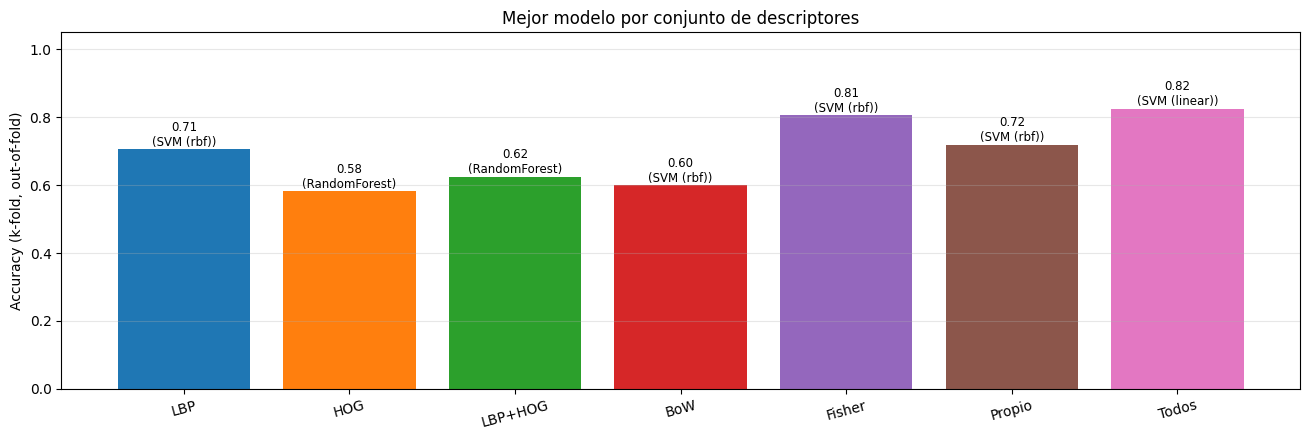

In [9]:
orden_descriptores = list(CONJUNTOS_DESCRIPTORES.keys())
mejor_por_descriptor = (tabla_resultados.sort_values("accuracy", ascending=False)
                                        .groupby("descriptor").first()
                                        .reindex(orden_descriptores))

fig, ax = plt.subplots(figsize=(1.6 * len(orden_descriptores) + 2, 4.5))
colores = plt.cm.tab10.colors
ax.bar(mejor_por_descriptor.index, mejor_por_descriptor["accuracy"],
       color=[colores[i % len(colores)] for i in range(len(mejor_por_descriptor))])
for i, (acc, modelo) in enumerate(zip(mejor_por_descriptor["accuracy"], mejor_por_descriptor["modelo"])):
    ax.text(i, acc + 0.01, f"{acc:.2f}\n({modelo})", ha="center", fontsize=8.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy (k-fold, out-of-fold)")
ax.set_title("Mejor modelo por conjunto de descriptores")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
guardar("07_comparacion_descriptores.png")
plt.show()

guardado: figs/08_matriz_confusion_mejor_modelo.png


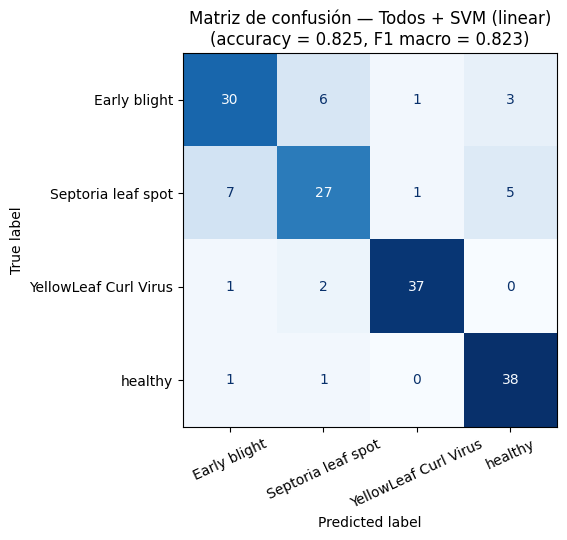


F1 por clase (mejor modelo global):
  Early blight             F1 = 0.759
  Septoria leaf spot       F1 = 0.711
  YellowLeaf Curl Virus    F1 = 0.937
  healthy                  F1 = 0.884


In [10]:
mejor_global = next(r for r in RESULTADOS
                     if r["descriptor"] == tabla_resultados.iloc[0]["descriptor"]
                     and r["modelo"] == tabla_resultados.iloc[0]["modelo"])

clases_orden = list(_le_global.classes_) if (TIENE_XGBOOST and mejor_global["modelo"] == "XGBoost") else sorted(set(y))
etiquetas_cortas = [etiqueta_corta(c) for c in clases_orden]

disp = ConfusionMatrixDisplay(confusion_matrix=mejor_global["cm"], display_labels=etiquetas_cortas)
fig, ax = plt.subplots(figsize=(6, 5.5))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=25, colorbar=False)
ax.set_title(f"Matriz de confusión — {tabla_resultados.iloc[0]['descriptor']} "
             f"+ {tabla_resultados.iloc[0]['modelo']}\n"
             f"(accuracy = {mejor_global['accuracy']:.3f}, F1 macro = {mejor_global['f1_macro']:.3f})")
plt.tight_layout()
guardar("08_matriz_confusion_mejor_modelo.png")
plt.show()

print("\nF1 por clase (mejor modelo global):")
for c in clases_orden:
    key = str(c)
    if key in mejor_global["reporte"]:
        print(f"  {etiqueta_corta(c):<24} F1 = {mejor_global['reporte'][key]['f1-score']:.3f}")

## 9. Conclusiones

**Mejor resultado global: "Todos" (LBP+HOG+BoW+Fisher+Propio concatenados) + SVM lineal**
-> accuracy = 0.825, F1 macro = 0.823 (k-fold, k=5, out-of-fold, 160 imágenes/4 clases).

### Por descriptor

- **Fisher Vector es, por lejos, el descriptor individual más fuerte** (0.81 con
  SVM rbf), muy por encima de LBP (0.71), Propio (0.72), LBP+HOG (0.62), BoW
  (0.60) y HOG (0.58). Tiene sentido: al codificar el gradiente respecto a
  medias *y* varianzas de un GMM de 32 componentes sobre descriptores SIFT
  densos, captura mucha más información por imagen (8192 dims) que un
  histograma de ocurrencias como BoW (64 dims).
- **Combinar LBP+HOG no ayudó** (0.62 con RandomForest, peor que LBP solo):
  con 1764 dimensiones de HOG contra apenas 40 imágenes por clase, HOG agrega
  más ruido de alta dimensión que señal cuando se concatena.
- **Combinar *todos* los descriptores sí ayudó** (0.825, mejor resultado
  general, por encima incluso de Fisher solo): acá el efecto es distinto
  porque Propio y BoW aportan información complementaria de bajo costo
  dimensional (16 y 64 dims) que no diluye a Fisher, a diferencia de lo que
  pasaba con HOG dentro de LBP+HOG.
- **BoW rindió peor de lo esperado** (0.60) pese a usar el mismo extractor
  SIFT denso que Fisher — el histograma de ocurrencias (k=64) pierde la
  información de segundo orden (varianza) que si aprovecha Fisher Vector.

### Por clasificador

- **SVM (lineal o rbf) fue consistentemente el mejor clasificador** en casi
  todos los conjuntos de descriptores de alta dimensión (Fisher, Todos,
  Propio) — con pocas muestras por clase y muchas dimensiones, un margen
  máximo generaliza mejor que kNN (sensible a la maldición de la
  dimensionalidad) o Random Forest (tiende a necesitar más muestras para
  no sobreajustar con tantas features).
- **kNN quedó consistentemente atrás** en los descriptores de alta dimensión,
  aunque fue competitivo en Fisher (0.77 con k=3-7).

### Matriz de confusión (mejor modelo: Todos + SVM lineal)

- **YellowLeaf Curl Virus (37/40) y hojas sanas (38/40) se clasifican casi
  perfectamente** — son las dos clases con el patrón visual más distintivo:
  deformación del contorno sin manchas focales, y ausencia total de lesiones,
  respectivamente.
- **El error se concentra entre Early blight y Septoria leaf spot** (6 y 7
  imágenes confundidas entre sí, del total de 13 errores en esas dos clases):
  ambas son manchas necróticas sobre tejido verde, y la diferencia principal
  entre ellas (anillos concéntricos grandes vs. muchas manchas chicas) es más
  una propiedad de forma/distribución espacial que de textura o color puros
  — es coherente con que el descriptor propio (que sí modela forma de
  manchas) ayude a distinguirlas mejor que LBP o BoW solos.

### Limitaciones

- Se usaron 4 de las 15 clases de PlantVillage y 40 imágenes por clase (160
  en total) para mantener el experimento manejable; con el dataset completo
  la brecha entre Fisher/SVM y los demás descriptores podría cambiar.
- No hay partición train/test independiente: todas las métricas son
  out-of-fold de un k-fold estratificado (k=5), no un test set separado del
  todo del proceso de selección de modelo.
- El vocabulario de BoW y el GMM de Fisher se ajustaron sobre las mismas 160
  imágenes que después se codifican (no hay un split train/test separado
  para el vocabulario) — en un informe más riguroso convendría ajustarlos
  solo sobre los folds de entrenamiento de cada iteración, no sobre todo el
  dataset de una vez.
